# Introduction

In the project [networks and graphs](https://drive.google.com/file/d/1TfxeXYXBvgiISUFx3HedB8zL17XJOe5M/view?usp=sharing), you created matrices that represented networks. **In this notebook you will learn how we can represent activity propagation in networks** by multiplying an **activity vector** by the **adjacency matrices**, such as the ones you have made priorly. In here we will be working with networks whose structure is both random and designed. As you work through this you will also acquire intuition about the evolution of the **network state** as a function of network structures, and will understand the role of **transfer functions** in neural network computation.

When activity enters the brain, it percolates its networks with cascading activity. This type of simple representation is a fair characterization of that process, and allows us to represent and study many types of brain activity including sleep and seizures.

# Learning Goals



- Understand activity propagation in discrete networks via vector-matrix multiplication.
- Understand propagation of activity in **feed forward** (FFNN) and **recurrent neural networks** (RNN).
- Acquire intuition about the evolution of the **activity state** for different network configurations.
- Understand the use of **saturating non-linearities** -- so called, 'transfer functions', such as logistic sigmoids (logsig),  the hyperbolic tangent (tanh) and rectifying linear units (ReLu), to represent neuronal ativity.

# Key Terms

- **Neuronal units**: nodes representing artificial neurons in a neural network.
- **Iterations**: steps in the computation of a discrete time neural network.
- **Transfer-function**: a function relating the input of a neuron to its output "activity".
- **Non-linearity**: any function relating two variables that is not simply a line (or a hyper-plane in N-Dimensions).
- **Saturation**: When a transfer function has a maximum output value.

# Pre-requisites

- Adjacency Matrix representation of graphs and networks.
- Vector Matrix Multiplication in numpy
- Computing functions over arrays (e.g., ```map()```)

# Initialization

In [1]:
# Colab/reproducibility setup: install only packages missing from this runtime.
import importlib.util
import subprocess
import sys

_required_packages = [
    ('ipywidgets', 'ipywidgets'),
]
_missing_packages = [
    package
    for module, package in _required_packages
    if importlib.util.find_spec(module) is None
]
if _missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing_packages])

In [2]:
import numpy as np
from numpy import zeros
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit # fast sigmoid computation

from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interactive_output


# A Minimal Neural Network

A discrete time neural network simulator is implemented below. It takes in an input vector (I), an adjacency matrix (W) and a number of steps that have to be computed (**iterations**). At every step, the new network activity is equal to the current activity vector (transposed, as a row) times the adjacency matrix, as such:

----

$$A_{t+1} = A_t ^T W $$

----

**Key Assumptions:**
- activity is an analog variable (e.g., a real number, in python a 'float')
- time is discrete: we compute the network in steps
  - hence, activity has a value for every step
  - delay between any two nodes in a network is equal to 1 time unit
- I-O function is linear: the nodes send exactly the same activity they receive

> **A self-check question:**. There are strict requirements for the shape of the input vector and the weight matrix. What are they?

In [3]:
# This is a minimal network

def NNet(W, I, steps):
  # initialize our output to save all the states of the network
  states = zeros((steps+1, len(W[0])))

  # we assign the input as the first state of our network
  states[0] = I

  # The future is computed from the past.
  # Note that range starts at '1', while the first state is at '0'
  for t in range(1,steps+1):
    states[t] = states[t-1]@W

  return states

## A Ring Network

Let us sanity check our network by looking at propagation of activity for a ring network (a ring network is a directed network where every neuron maps to the subsequent neuron and the last connects to the first).


### Example: Propagation in a Ring Network

1. Make the adjacency matrix ```W``` for a ring network with three neurons where the first neuron connects to the second, the second to the third and the third to the first. For example, make a python list and convert it (i.e., 'cast it') to a 2-D numpy array (```np.array```) representing a matrix.

2. Make an input vector ```I``` to represent the initial input to the network where the first neuron has activity 1 and other neurons have activity 0. Cast it as an 1-D array, and make it sure you know the orientation of the vector (column or row)?

In [4]:
# A 3 neuron ring network (directed, unweighted)

W = np.array([[0,1,0],[0,0,1],[1,0,0]])

# I - initial state: Input to the first neuron on the first iteration

I = np.array([1,0,0])

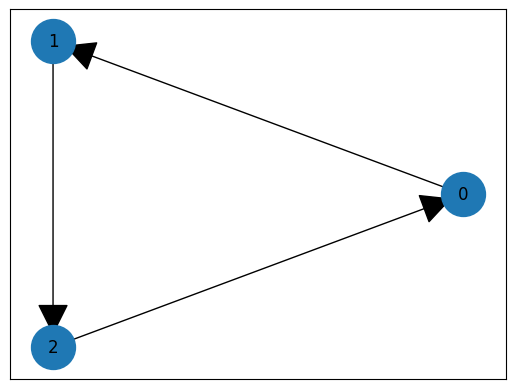

In [5]:
# Visualize the Network

G = nx.from_numpy_array(W, create_using = nx.MultiDiGraph())

pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos,  node_size = 1000)
nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edges(G, pos, arrows=True, arrowsize = 50)

plt.show()

Text(0, 0.5, 'neurons')

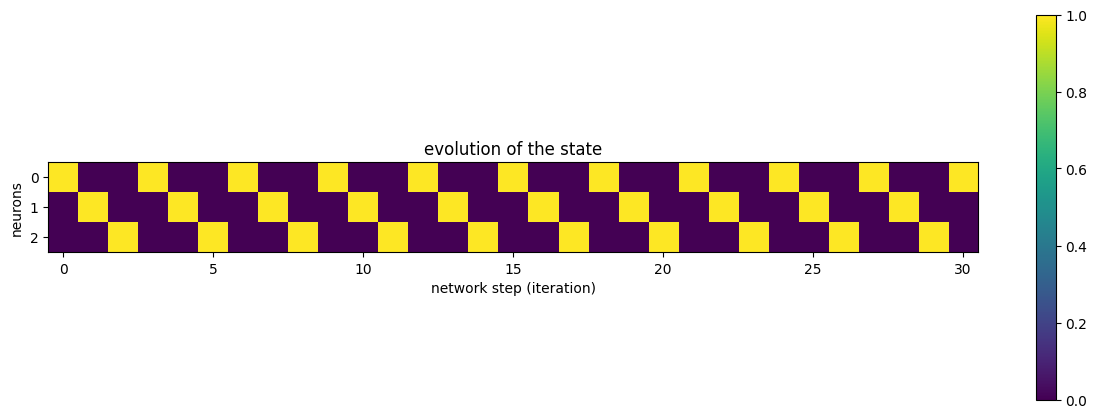

In [6]:
 # Here we run the network and show the resulting activity
R= NNet(W,I.T,30) # we use the transpose

plt.figure(figsize=(15,5))
plt.imshow(R.T) # T here means transpose
plt.colorbar()
plt.title('evolution of the state')
plt.xlabel('network step (iteration)')
plt.ylabel('neurons')

In [7]:
# A tiny widget to visualize the progression of the net activity

def net_activity(results, netgraph, timestep):
  pos = nx.circular_layout(netgraph)
  fig, ax = plt.subplots(figsize=(6, 6))
  nx.draw_networkx_nodes(netgraph, pos, node_size=300, node_color=results[timestep], cmap='Set3', ax=ax)
  nx.draw_networkx_labels(netgraph, pos, ax=ax)
  nx.draw_networkx_edges(netgraph, pos, arrows=True, arrowsize=30, connectionstyle='arc3, rad=0.3', ax=ax)
  ax.set_title(f'Network step {timestep}')
  ax.set_axis_off()
  plt.show()

step_slider = widgets.IntSlider(min=0, max=R.shape[0]-1, step=1, value=0, description='step', continuous_update=False)
output = interactive_output(lambda timestep: net_activity(R, G, timestep), {'timestep': step_slider})
display(widgets.VBox([step_slider]), output)


Output()

# A Feed-forward Network

## Create a Feed Forward Network

- For a feed-forward network the network will have both an input layer and an output layer. Make a FFNN network with 9 input neurons in the first layer and 5 output neurons in the second layer. Connections should come strictly from layer 1 to layer 2.
- No lateral connections: neurons in one layer do not connect to other neurons in the same layer.
- For the existing connections, make all weights equal to 1.
- Create a random input vector and give it to your network function.
- Compute as many steps of the network as are necessary for the input to reach the output layer.
- Display and reason about the resulting network and activity.

**Note**: To display a layered network you have to define the argument 'position' of ```networkx``` network plotting package. Note that we have been creating pos via ```pos= nx.circular_layout(G)``` but you can use simply the x and y positions of the nodes (in a list).

#### Your Solution

[[1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]]
[[0.08064889 0.35478751 0.78150167 0.8960804  0.82642441 0.92544688
  0.31314937 0.65198604 0.00260976]]


Text(0.5, 0, 'neurons')

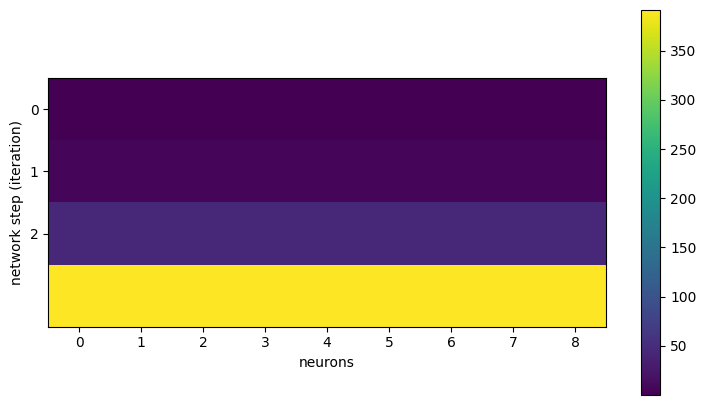

In [8]:
ffW = np.ones(shape=(9,9))
print(ffW)
ffR = np.random.uniform(size=(1,9))
print(ffR)

R= NNet(ffW,ffR,3)

plt.figure(figsize=(9,5))
plt.imshow(R)
plt.colorbar()
plt.ylabel('network step (iteration)')
plt.yticks([0,1,2])
plt.xlabel('neurons')

#### Our Solution

In [9]:
## Create Input and Connectivity Matrix

ffW = zeros(shape=(14,14))
ffW[0:9,9:14] = 1
print(ffW)

# beware: in python, 'shape' and 'size' maybe used confusingly.
ffR = np.random.uniform(size=(1,14))
print(ffR)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0.98945635 0.78302584 0.23478707 0.51613734 0.85061334 0.81660072
  0.30726388 0.60874495 0.58931695 0.83167575 0.60844376 0.01376205
  0.5169137  0.74697428]]


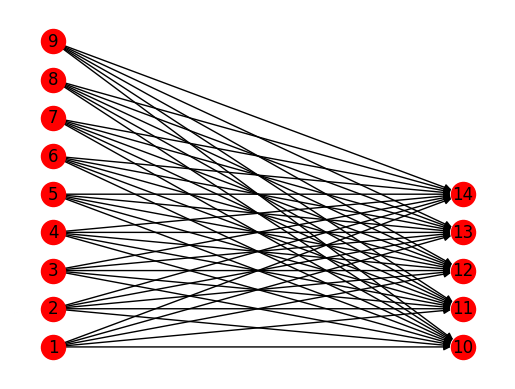

In [10]:
## Create graphs and display

GffW = nx.from_numpy_array(ffW, create_using=nx.MultiDiGraph())
pos = {0:(1,0),1:(1,1),2:(1,2),3:(1,3),4:(1,4),5:(1,5),6:(1,6),7:(1,7),8:(1,8),9:(3,0),10:(3,1),11:(3,2),12:(3,3),13:(3,4)}

#xy = np.asarray([pos[v] for v in nodelist])
GffW.graph['edge'] = {'arrowsize': '100', 'splines': 'curved'}

#nx.set_node_attributes(GffW,'coord', pos)

labels={0:1,1:2,2:3,3:4,4:5,5:6,6:7,7:8,8:9,9:10,10:11,11:12,12:13,13:14}

nx.draw_networkx_labels(GffW, pos, labels, font_size=12)

nx.draw(GffW,pos,node_color='r')



##### Compute the Network Activity

Text(0, 0.5, 'neurons')

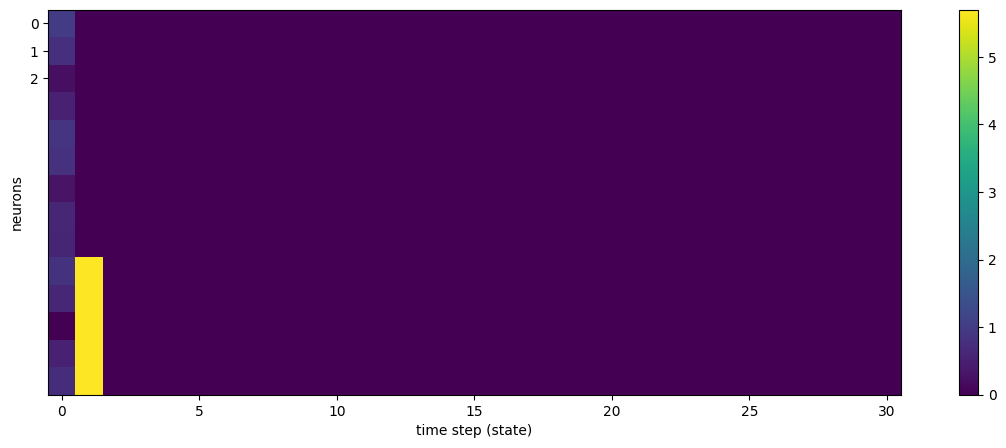

In [11]:
## compute the network activity with our NNet function
R= NNet(ffW,ffR,30)

plt.figure(figsize=(15,5))
plt.imshow(R.T)
plt.colorbar()
plt.ylabel('network step (iteration)')
plt.yticks([0,1,2])
plt.xlabel('time step (state)')
plt.ylabel('neurons')

### Questions:
1. What is the initial state of the network?
2. What is the final state of the network?

### Answers
The initial state is simply the weigthed sum of the input, and the "final"  state is "quiescence" / zero, a big silence.

# Activity propagation in Random RNNs

## Exercise: The activity of RRNN's

- These subsequent notes will hopefully lead you to understand why  non-linear transfer functions (such as the logistic sigmoid) are commonly used in neural network computations.

First, create a 5x5 random matrix with random input from the uniform distribution [-1,1].

In [12]:
# Let's create a random matrix with a random input
randomW = np.random.uniform(-1,1,size=(25,25))
randomI = np.random.uniform(-1,1,size=(1,25))

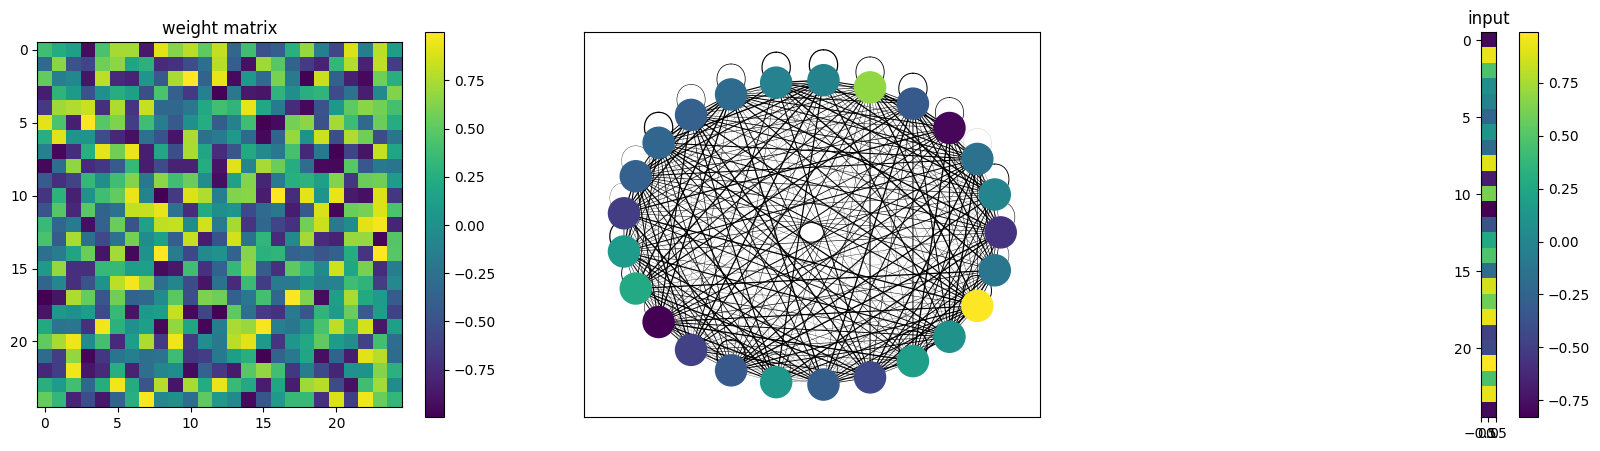

In [13]:
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.imshow(randomW)
plt.title('weight matrix')
plt.colorbar()

plt.subplot(1,3,2)
randomG = nx.from_numpy_array(randomW)
edges, weights = zip(*nx.get_edge_attributes(randomG,'weight').items())
pos = nx.circular_layout(randomG)
nx.draw_networkx_edges(randomG, pos, arrows=True, width=weights)
nx.draw_networkx_nodes(randomG, pos,  node_size = 500, node_color=np.sum(a=randomW, axis=0))

plt.subplot(1,3,3)
plt.imshow(randomI.T)
plt.title('input')
plt.colorbar();

In the code below, run the network with 5, 10 and 30 time steps, always with the same input and matrix. What is the strange thing that happens?

## Run the network for a few time steps

Text(0, 0.5, 'neurons')

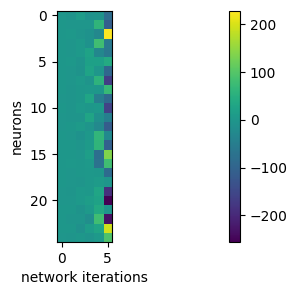

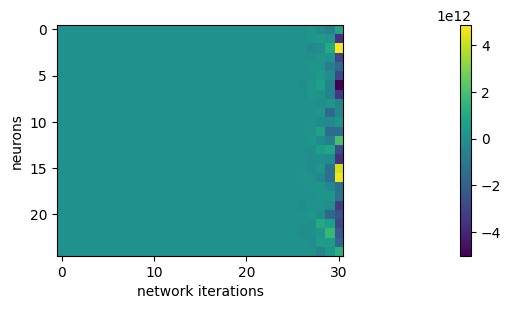

In [14]:
# Exercise 3.2
R= NNet(randomW,randomI,5)

plt.figure(figsize=(30,3))
plt.imshow(R.T)
plt.colorbar()
plt.xlabel('network iterations')
plt.ylabel('neurons')

# Exercise 3.2
R= NNet(randomW,randomI,30)

plt.figure(figsize=(30,3))
plt.imshow(R.T)
plt.colorbar()
plt.xlabel('network iterations')
plt.ylabel('neurons')

## Question: Why is activity appearing all green in the first time steps?
- Notice the scale of the colorbar on the right. Why is the value so large (1e9 means 10^9)? (have a look at the units of the colorbar)
- Compare the values of the activity of the network in the second time step with the last time step (print them out, the numbers). Why is the difference so humongous?

In [15]:
print("first step:"+ str(R[0, 0:13]))
print("fifth step:"+ str(R[4, 0:13]))
print("last step:" + str(R[28, 0:13]))

first step:[-0.79187192  0.93702371  0.48390063  0.06615892 -0.03169755 -0.23901735
  0.11442676 -0.18900615  0.90399779 -0.69230066  0.61673979 -0.83041853
 -0.36615147]
fifth step:[-7.30482935e+00  6.01082256e+01 -2.87766011e+01  7.89983591e+01
 -3.12947889e+01  2.02617972e+01 -3.67393892e-01  5.69792776e+01
  7.51000200e-02 -4.81464418e+01  2.79718967e+00 -1.17364951e+01
 -2.77407395e+01]
last step:[-2.49680493e+11  3.04352781e+11 -1.36460927e+11  2.28274705e+11
  1.01298502e+11  3.42779277e+11  5.59775579e+11  3.77104517e+10
 -5.79799616e+10  1.45537813e+11 -2.19753975e+11  6.61827814e+11
 -2.18178083e+11]


Answer:

- The initial activity is dwarved by end states which are diverging, since the output of the individual units is not bounded. Technically the network activity grows exponentially.


## A Non-linear Transfer Function

As you probably figured out aeons ago, the activity of the random network above is 'unbouded', that is, for every iteration the activity grows (because we keep on multiplying the activity vector by the weight matrix and summing). The neuron's activities become larger and larger. That is not very plausible, as neurons in general have a maximum possible firing rate they can produce. **How to keep the outputs of the neuron bounded?**

This is your second encounter with the concept of a **transfer function**, in this case a "saturating" non-linearity (note that the Heaviside function is also a tansfer function). A transfer function transforms the input space to an output space. In neural networks the transfer function *often* serves the purpose of constraining the output space to a bounded interval, to represent bounded activity of neurons. Note that in machine learning, some transfer functions may not be bounded, e.g. ReLu.

Earlier you learned about the Heaviside transfer function. It constrains the output to two values (ie.e, min/max, 0/1) but the change of output is very abrupt. One way to achieve a smoother mapping of a *real number* from minus infinity to infinity into a number between zero and one is via the logistic sigmoid:

---

$$f(x) = \frac{1}{1+e^{-x}}$$

---

This function can be thought of as representing a degree of certainty. For very negative values you become very confident on a 'no' and vice-versa. For values close to zero, 0.5 represents you `don't know', a 50/50.

### Warm-up: Write a python function that returns a sigmoid of its input

- Write the python function
- Plot the function in the range between [-10:10]

#### Your Code

#### Our Code

Text(0, 0.5, 'f(x)')

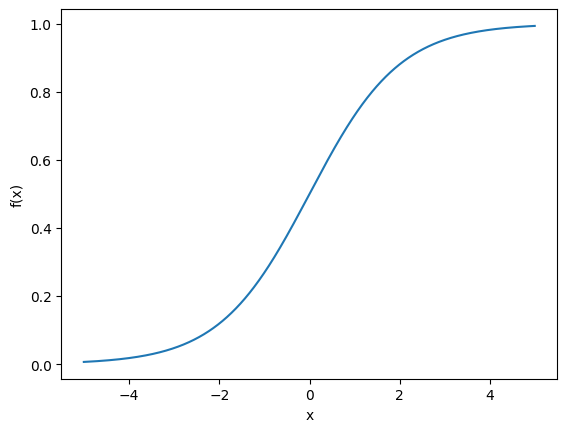

In [16]:
# Exercise 3.3 define and plot sigmoid
def sigmoid(x):
  return 1./(1.+np.exp(-x))

x = np.arange(-5,5,0.01)

plt.plot(x, sigmoid(x))
plt.xlabel('x')
plt.ylabel('f(x)')

### Exercise: Add your sigmoid function to the FFnet function

This is (the standard) equation that computes the iterates of networks and applies some transfer function F(x):

---
In vector matrix format:

$$
\mathbf{A}(t+1) = F(\mathbf{A}^T(t)\mathbf{W})
$$

From the perspective of the single neuron $i$ that receives from neurons $j$:

$$a_i(t+1) = \sum^{n}_{j=1} F (w_{ij} a_j (t))$$

---

- Modify the network equation to include this transfer function
- Plot the activity of the network and interpret
- Try your new network with different random matrices and inputs:
  - different sizes
  - try multiplying your weigths but a single constant value (i.e., W*constant)
  - try shifting your weigths but a single constant value (i.e., W + constant). Use negative values as well!


#### Your Code

#### Our Code

In [17]:
# Exercise 3.4
def NNet_TF(W, I, steps):
    states = zeros((steps, len((W[0]))))
    states[0] = I
    for t in range(1,steps):
        states[t] = expit(states[t-1]@(W*30.))
    return states

(30, 3)


Text(0, 0.5, 'neuron')

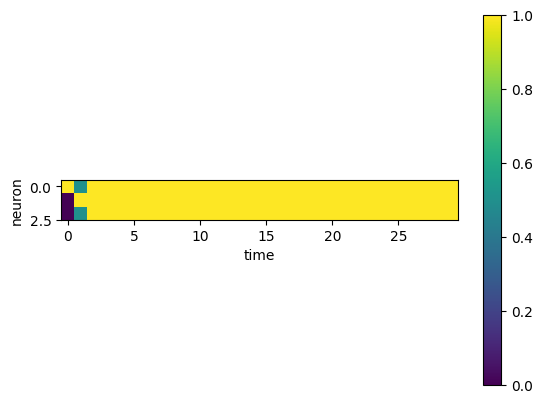

In [18]:
R= NNet_TF(W,I,30)

print(R.shape)
plt.figure
plt.imshow(R.T)
plt.colorbar()
plt.xlabel('time')
plt.ylabel('neuron')

## Discussion

Despite its simplicity, variants on this type of network as above has been often used to explain the interaction between many brain areas. In terms of plausibility, the sigmoid function appears as a natural consequence of the activity of networks of homogeneous (read, 'similar') spiking neurons. Theoretically, the reduction from spiking neurons into sigmoidal activation functions is called the **mean field approximation**, which is very often employed in the field of "Whole Brain Modeling".

In here we have used a **discrete time** variant of these networks. The adaptation from discrete time to continuous time is a simple matter of convering the difference equations( $F(t+1) = f(t)$ into differential equations ($dF/dt = f(t)$). There are many similarities, but some differences in the dynamics of the two approaches, and these have been significantly analysed in the scientific literature.

# Questions

- What operation in linear algebra is used to represent the propagation of activity in a network?
- What is the role of transfer functions?
- Which network topologies can generate spontaneous activity over time?
- The logistic sigmoid has the output domain bounded to [0,1], and the hyperbolic tangent has output domain [-1,1]. Which one can best represent the activity of neuronal areas?


### Answer

- vector matrix multiplication
- map the input to the output, non-linear transfer functions constrain the output to a finite range
- Recurrence. given bias units (baseline activity level), reciprocal connections, rings, and random networks.
- since negative activities do not make intuitive sense, we generaelly prefer sigmoids to represent brain areas.

# Mull Over

- how to transform discrte into continuous? What is the relationship between difference equations and differential equation?

https://en.wikipedia.org/wiki/Euler_method

#License

<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>. Mario Negrello, Daphne Cornelisse (2020).